# 1. Latar Belakang & Permasalahan

Harga sembako merupakan kebutuhan pokok masyarakat yang cenderung mengalami fluktuasi dari waktu ke waktu.

## Permasalahan
Bagaimana mempersiapkan dataset harga sembako yang bersih dan siap digunakan untuk pemodelan prediksi harga?

## Solusi
Melakukan proses data wrangling secara end-to-end serta feature engineering untuk menghasilkan dataset yang siap digunakan untuk modeling.

# 2. Pertanyaan Bisnis

1. Bagaimana tren harga masing-masing komoditas dari waktu ke waktu?
2. Apakah terdapat pola dalam pergerakan harga?
3. Bagaimana mempersiapkan dataset agar siap digunakan untuk modeling?

# 3. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 4. Data Gathering

Menggabungkan beberapa dataset komoditas menjadi satu dataframe untuk memudahkan analisis.

In [2]:
beras = pd.read_csv('../data/raw/komoditas_beras_2022_2026.csv')
gula = pd.read_csv('../data/raw/komoditas_gula_pasir_2022_2026.csv')
minyak = pd.read_csv('../data/raw/komoditas_minyak_goreng_2022_2026.csv')
telur = pd.read_csv('../data/raw/komoditas_telur_ayam_2022_2026.csv')

beras['komoditas'] = 'beras'
gula['komoditas'] = 'gula'
minyak['komoditas'] = 'minyak'
telur['komoditas'] = 'telur'

df_raw = pd.concat(
    [beras, gula, minyak, telur],
    ignore_index=True
)

df_raw.head()

,Date_Scraped,Date_Param,Commodity_ID,Commodity_Name,Province_ID,Province_Name,Price,Price_Type,komoditas
0,2026-02-12,2022-01-01,1,Beras,1,Aceh,10250.0,1,beras
1,2026-02-12,2022-01-01,1,Beras,2,Sumatera Utara,11150.0,1,beras
2,2026-02-12,2022-01-01,1,Beras,3,Sumatera Barat,13250.0,1,beras
3,2026-02-12,2022-01-01,1,Beras,4,Riau,12250.0,1,beras
4,2026-02-12,2022-01-01,1,Beras,5,Kepulauan Riau,13550.0,1,beras


In [3]:
#Export Data Gabungan

df_raw.to_csv(
    '../data/raw/sembako_gabungan_raw.csv',
    index=False
)

## 3. Data Assessing

Melakukan pengecekan kualitas data.

In [4]:
df_raw.info()

df_raw.isnull().sum()

df_raw.duplicated().sum()

df_raw.describe()

df_raw['komoditas'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188832 entries, 0 to 188831
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Date_Scraped    188832 non-null  object 
 1   Date_Param      188832 non-null  object 
 2   Commodity_ID    188832 non-null  int64  
 3   Commodity_Name  188832 non-null  object 
 4   Province_ID     188832 non-null  int64  
 5   Province_Name   188832 non-null  object 
 6   Price           188832 non-null  float64
 7   Price_Type      188832 non-null  int64  
 8   komoditas       188832 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 13.0+ MB


komoditas
beras     47211
gula      47211
telur     47211
minyak    47199
Name: count, dtype: int64

## 4. Data Cleaning

Membersihkan data agar siap digunakan.

In [5]:
# Rename kolom agar lebih mudah dipakai
df_raw = df_raw.rename(columns={
    'Date_Param': 'date',
    'Province_Name': 'provinsi',
    'Commodity_Name': 'commodity_name',
    'Price': 'price'
})

# Mengubah tipe data tanggal
df_raw['date'] = pd.to_datetime(df_raw['date'])

# Mengurutkan data berdasarkan tanggal
df_raw = df_raw.sort_values('date')

# Menghapus duplikat
df_raw = df_raw.drop_duplicates()

df_raw.head()

,Date_Scraped,date,Commodity_ID,commodity_name,Province_ID,provinsi,price,Price_Type,komoditas
0,2026-02-12,2022-01-01,1,Beras,1,Aceh,10250.0,1,beras
47216,2026-02-12,2022-01-01,10,Gula Pasir,6,Jambi,13550.0,1,gula
47215,2026-02-12,2022-01-01,10,Gula Pasir,5,Kepulauan Riau,11700.0,1,gula
47214,2026-02-12,2022-01-01,10,Gula Pasir,4,Riau,12900.0,1,gula
47213,2026-02-12,2022-01-01,10,Gula Pasir,3,Sumatera Barat,14450.0,1,gula


## 5. Agregasi Nasional

Dilakukan agregasi untuk mendapatkan harga rata-rata nasional per komoditas.

In [6]:
df_nasional = df_raw.groupby(
    ['date', 'komoditas']
).agg({
    'price': 'mean'
}).reset_index()

df_nasional.head()

,date,komoditas,price
0,2022-01-01,beras,11732.352941
1,2022-01-01,gula,14117.647059
2,2022-01-01,minyak,19892.647059
3,2022-01-01,telur,30298.529412
4,2022-01-02,beras,11732.352941


In [7]:
df_nasional.to_csv(
    '../data/processed/sembako_nasional.csv',
    index=False
)

## 6. Exploratory Data Analysis

Analisis dilakukan untuk melihat pola harga setelah agregasi nasional.

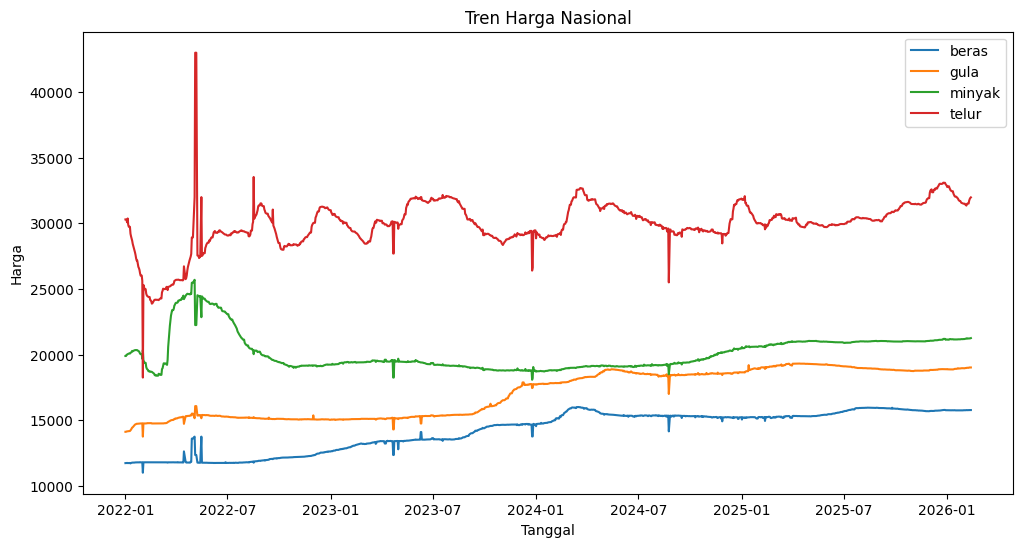

In [8]:
plt.figure(figsize=(12,6))

for komoditas in df_nasional['komoditas'].unique():

    subset = df_nasional[
        df_nasional['komoditas'] == komoditas
    ]

    plt.plot(
        subset['date'],
        subset['price'],
        label=komoditas
    )

plt.title("Tren Harga Nasional")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()

plt.show()

### Insight Tren Harga

Berdasarkan grafik tren harga nasional, setiap komoditas menunjukkan pola perubahan harga yang berbeda selama periode pengamatan.

Beberapa komoditas mengalami kenaikan harga secara bertahap, sementara komoditas lainnya menunjukkan fluktuasi yang lebih tinggi pada periode tertentu. 

Hasil agregasi nasional membantu memperlihatkan pola umum harga sehingga tren lebih mudah diamati dibanding data per wilayah.

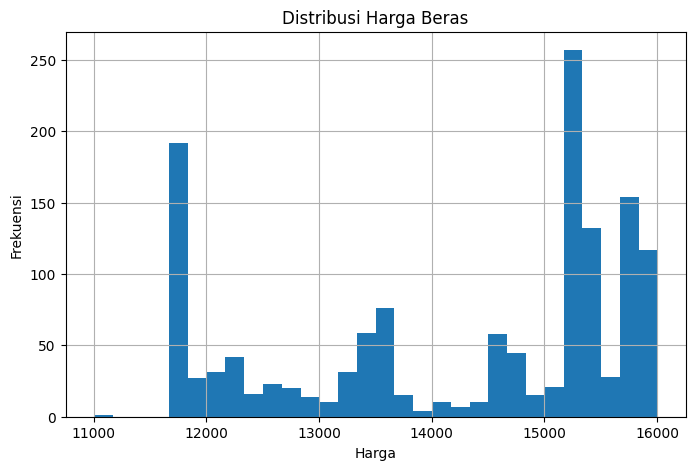

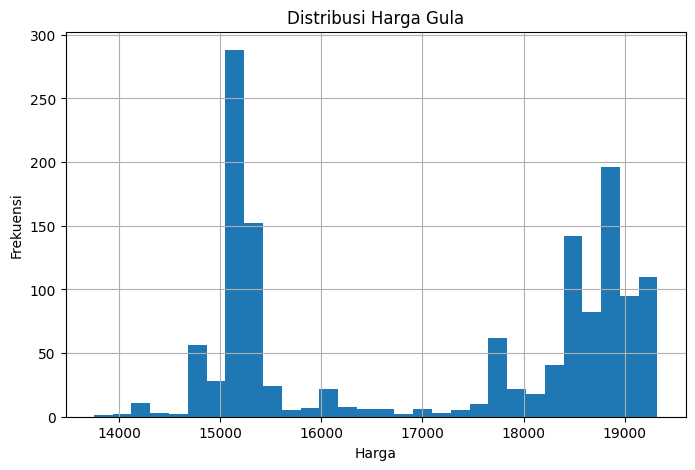

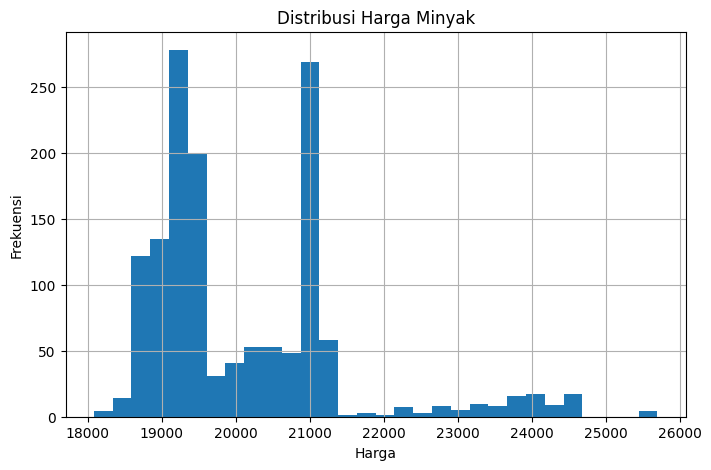

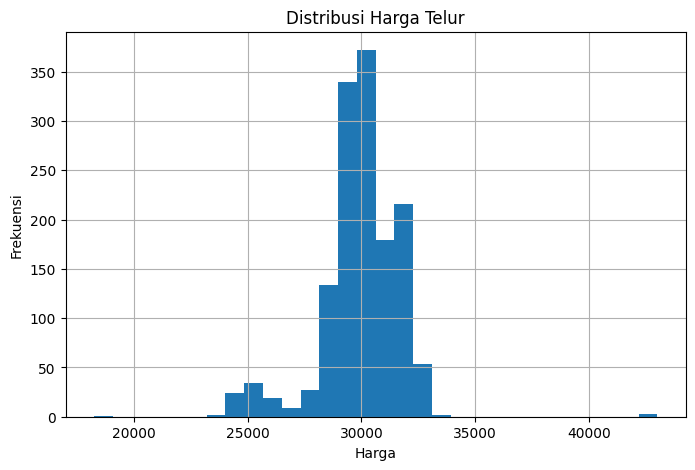

In [9]:
# Distribusi Harga per Komoditas

for komoditas in df_nasional['komoditas'].unique():

    subset = df_nasional[
        df_nasional['komoditas'] == komoditas
    ]

    plt.figure(figsize=(8,5))

    subset['price'].hist(bins=30)

    plt.title(f"Distribusi Harga {komoditas.capitalize()}")
    plt.xlabel("Harga")
    plt.ylabel("Frekuensi")

    plt.show()

### Insight Distribusi Harga

Distribusi harga menunjukkan persebaran harga pada masing-masing komoditas.

Beberapa komoditas memiliki distribusi yang lebih lebar, yang menandakan variasi harga yang lebih tinggi. Sementara itu, distribusi yang lebih sempit menunjukkan harga yang relatif stabil selama periode pengamatan.

<Figure size 1000x600 with 0 Axes>

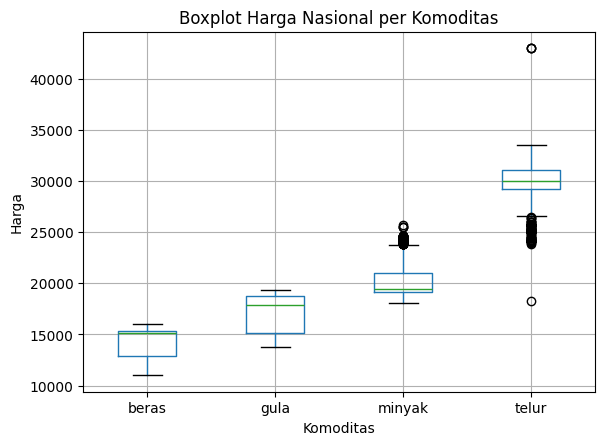

In [10]:
# Boxplot Harga per Komoditas

plt.figure(figsize=(10,6))

df_nasional.boxplot(
    column='price',
    by='komoditas'
)

plt.title("Boxplot Harga Nasional per Komoditas")
plt.suptitle("")

plt.xlabel("Komoditas")
plt.ylabel("Harga")

plt.show()

### Insight Boxplot

Berdasarkan boxplot, terdapat perbedaan persebaran harga pada masing-masing komoditas.

Komoditas telur menunjukkan rentang harga yang paling tinggi dibanding komoditas lain. Selain itu, terdapat beberapa outlier pada komoditas telur dan minyak goreng yang mengindikasikan adanya lonjakan harga ekstrem pada periode tertentu.

Outlier tersebut dapat disebabkan oleh faktor pasar seperti perubahan pasokan, permintaan, inflasi, maupun kondisi ekonomi tertentu.

Sementara itu, komoditas beras memiliki persebaran harga yang relatif lebih stabil karena rentang harga dan jumlah outlier yang lebih sedikit dibanding komoditas lainnya.

In [11]:
# Statistik Deskriptif
df_nasional.groupby('komoditas')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
komoditas,,,,,,,,
beras,1415.0,14239.736627,1497.582810,11000.0,12858.088235,15098.387097,15369.117647,16004.411765
gula,1415.0,17134.710047,1757.993558,13750.0,15188.235294,17832.352941,18803.676471,19323.529412
minyak,1415.0,20107.742295,1339.228384,18080.0,19139.549911,19483.823529,20986.764706,25700.000000
telur,1415.0,29945.887595,1788.492308,18250.0,29222.794118,30013.235294,31068.382353,43000.000000


### Insight Statistik Deskriptif

Berdasarkan statistik deskriptif, setiap komoditas memiliki karakteristik harga yang berbeda selama periode pengamatan.

Komoditas telur memiliki rata-rata harga tertinggi, yaitu sekitar 29.944, dengan harga maksimum mencapai 43.000. Hal ini menunjukkan bahwa telur termasuk komoditas dengan harga relatif tinggi dan memiliki lonjakan harga yang cukup besar pada periode tertentu.

Komoditas minyak goreng memiliki rata-rata harga sekitar 20.108 dengan harga maksimum mencapai 25.700. Variasi harga minyak goreng terlihat cukup besar, terutama pada beberapa periode ketika terjadi kenaikan harga.

Komoditas gula pasir memiliki standar deviasi tertinggi dibanding komoditas lain, yaitu sekitar 1.749. Hal ini menunjukkan bahwa gula memiliki tingkat fluktuasi harga yang paling tinggi selama periode pengamatan.

Sementara itu, beras memiliki distribusi harga yang relatif lebih stabil dibanding komoditas lainnya, terlihat dari standar deviasi yang lebih rendah serta rentang harga yang tidak terlalu jauh.

## 7. Explanatory Analysis

Berdasarkan hasil exploratory data analysis (EDA), setiap komoditas menunjukkan pola harga yang berbeda selama periode pengamatan tahun 2022–2026.

Visualisasi tren harga menunjukkan bahwa harga komoditas nasional mengalami fluktuasi dari waktu ke waktu. Beberapa komoditas mengalami kenaikan harga secara bertahap, sementara komoditas lain menunjukkan perubahan harga yang lebih tajam pada periode tertentu.

Hasil distribusi harga dan boxplot menunjukkan bahwa tingkat persebaran harga pada masing-masing komoditas juga berbeda. Komoditas seperti gula pasir dan telur memiliki variasi harga yang lebih besar dibanding komoditas lain, yang terlihat dari rentang distribusi serta keberadaan beberapa outlier pada boxplot.

Selain itu, terdapat beberapa outlier pada data harga yang mengindikasikan adanya lonjakan harga ekstrem pada periode tertentu. Kondisi tersebut dapat dipengaruhi oleh faktor ekonomi, perubahan pasokan, permintaan pasar, maupun inflasi.

Setelah dilakukan agregasi nasional, pola harga menjadi lebih stabil sehingga lebih mudah digunakan untuk analisis lanjutan dan proses modeling time series.

## 8. Data Preparation

Menambahkan fitur-fitur pendukung untuk modeling time series.

In [12]:
df_features = df_nasional.copy()

# Feature tanggal
df_features['year'] = df_features['date'].dt.year
df_features['month'] = df_features['date'].dt.month
df_features['day'] = df_features['date'].dt.day

# Mengurutkan data
df_features = df_features.sort_values(
    ['komoditas', 'date']
)

# Lag feature
df_features['lag_1'] = (
    df_features.groupby('komoditas')['price']
    .shift(1)
)

df_features['lag_7'] = (
    df_features.groupby('komoditas')['price']
    .shift(7)
)

# Rolling mean
df_features['rolling_mean_7'] = (
    df_features.groupby('komoditas')['price']
    .transform(lambda x: x.rolling(7).mean())
)

# Menghapus missing value hasil feature engineering
df_features = df_features.dropna()

df_features.head()

,date,komoditas,price,year,month,day,lag_1,lag_7,rolling_mean_7
28,2022-01-08,beras,11741.176471,2022,1,8,11741.176471,11732.352941,11738.865546
32,2022-01-09,beras,11741.176471,2022,1,9,11741.176471,11732.352941,11740.126050
36,2022-01-10,beras,11710.294118,2022,1,10,11741.176471,11738.235294,11736.134454
40,2022-01-11,beras,11745.588235,2022,1,11,11710.294118,11748.529412,11735.714286
44,2022-01-12,beras,11758.823529,2022,1,12,11745.588235,11733.823529,11739.285714


## 9. Export Dataset

In [14]:
df_features.to_csv(
    '../data/processed/sembako_nasional_features.csv',
    index=False
)

## 10. Data Dictionary

| Kolom | Deskripsi |
|---|---|
| `date` | Tanggal data |
| `komoditas` | Jenis komoditas |
| `price` | Harga rata-rata nasional |
| `year` | Tahun |
| `month` | Bulan |
| `day` | Hari |
| `lag_1` | Harga 1 hari sebelumnya |
| `lag_7` | Harga 7 hari sebelumnya |
| `rolling_mean_7` | Rata-rata harga 7 hari |

## Business Questions Answers

### 1. Bagaimana tren perubahan harga nasional pada masing-masing komoditas dari waktu ke waktu?

Harga nasional pada setiap komoditas menunjukkan pola fluktuatif sepanjang periode pengamatan. 
Beberapa komoditas mengalami kenaikan harga pada periode tertentu dan penurunan pada periode lainnya. 
Meskipun demikian, setelah dilakukan agregasi nasional, pola tren harga terlihat lebih stabil dan lebih mudah dianalisis.

---

### 2. Komoditas apa yang memiliki fluktuasi harga paling tinggi selama periode pengamatan?

Komoditas dengan fluktuasi harga paling tinggi dapat dilihat dari perubahan harga yang paling tajam pada grafik tren maupun distribusi data. 
Berdasarkan hasil EDA, komoditas dengan rentang harga dan variasi terbesar menunjukkan tingkat volatilitas yang lebih tinggi dibanding komoditas lainnya.

---

### 3. Apakah terdapat pola kenaikan atau penurunan harga tertentu pada komoditas sembako nasional?

Hasil analisis menunjukkan bahwa terdapat pola perubahan harga pada beberapa periode tertentu. 
Kenaikan dan penurunan harga cenderung terjadi secara bertahap, serta dipengaruhi oleh kondisi pasar dan perubahan permintaan. 
Pola tersebut dapat diamati dengan lebih jelas melalui visualisasi tren harga nasional tiap komoditas.

## Conclusion

Berdasarkan hasil analisis data harga sembako nasional periode 2022–2026, dapat disimpulkan bahwa setiap komoditas memiliki pola pergerakan harga yang berbeda-beda. Harga komoditas mengalami fluktuasi dari waktu ke waktu dengan tingkat perubahan yang bervariasi pada masing-masing komoditas.

Hasil exploratory data analysis menunjukkan bahwa beberapa komoditas memiliki tingkat volatilitas harga yang lebih tinggi dibanding komoditas lainnya. Hal ini terlihat dari distribusi harga, boxplot, serta nilai statistik deskriptif yang menunjukkan perbedaan persebaran dan variasi harga pada setiap komoditas.

Selain itu, ditemukan beberapa outlier pada data harga yang mengindikasikan adanya lonjakan harga ekstrem pada periode tertentu. Kondisi tersebut dapat dipengaruhi oleh faktor ekonomi, perubahan pasokan, permintaan pasar, maupun inflasi.

Setelah dilakukan agregasi nasional, pola harga menjadi lebih stabil dan lebih mudah digunakan untuk analisis lanjutan. Feature engineering yang dilakukan juga berhasil menambahkan informasi historis melalui fitur lag dan rolling mean sehingga dataset siap digunakan untuk proses modeling dan forecasting harga komoditas.